In [23]:
import pandas as pd
import numpy as np
import joblib
import pickle
import re
import os

from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Layer
import tensorflow as tf


# ==========================================
# CREATE ENSEMBLE SAVE FOLDER
# ==========================================

os.makedirs("models/ensembles", exist_ok=True)


# ==========================================
# CUSTOM ATTENTION LAYER
# ==========================================

class AttentionLayer(Layer):

    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):

        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], input_shape[-1]),
            initializer='glorot_uniform',
            trainable=True
        )

        self.b = self.add_weight(
            name='attention_bias',
            shape=(input_shape[-1],),
            initializer='zeros',
            trainable=True
        )

        self.u = self.add_weight(
            name='context_vector',
            shape=(input_shape[-1],),
            initializer='glorot_uniform',
            trainable=True
        )

        super(AttentionLayer, self).build(input_shape)

    def call(self, x):

        score = tf.nn.tanh(tf.tensordot(x, self.W, axes=[2,0]) + self.b)

        attention_weights = tf.nn.softmax(
            tf.tensordot(score, self.u, axes=[2,0]),
            axis=1
        )

        context_vector = tf.reduce_sum(
            attention_weights[..., tf.newaxis] * x,
            axis=1
        )

        return context_vector


# ==========================================
# LOAD MODELS
# ==========================================

print("Loading models...")

rf = joblib.load("models/random_forest_model.pkl")
svm = joblib.load("models/svm_model.pkl")
lr = joblib.load("models/logistic_regression_model.pkl")
xgb = joblib.load("models/xgboost_model.pkl")

label_encoder = joblib.load("models/label_encoder.pkl")

bilstm_model = load_model(
    "models/disease_prediction_model.h5",
    custom_objects={"AttentionLayer": AttentionLayer}
)

with open("models/preprocessing.pkl", "rb") as f:
    preprocess = pickle.load(f)

tokenizer = preprocess["tokenizer"]

max_len = 150

print("Models loaded successfully")


# ==========================================
# TEXT CLEANING
# ==========================================

def clean_text(text):

    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text


# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("dataset/ensemble_dataset.csv")

texts = df["text"]
X_tab = df.drop(["text", "label"], axis=1)
labels = df["label"]

y = label_encoder.transform(labels)


# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_text_train, X_text_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    texts,
    X_tab,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


# ==========================================
# BILSTM PREDICTION
# ==========================================

def bilstm_predict_batch(texts):

    cleaned = [clean_text(t) for t in texts]

    seq = tokenizer.texts_to_sequences(cleaned)

    pad = pad_sequences(seq, maxlen=max_len)

    probs = bilstm_model.predict(pad, verbose=0)

    return probs


# ==========================================
# BiLSTM + RF + SVM + LR + XGBoost
# ==========================================

def evaluate_bilstm_rf_svm_lr_xgboost():

    text_probs = bilstm_predict_batch(X_text_test)

    rf_probs = rf.predict_proba(X_tab_test)
    svm_probs = svm.predict_proba(X_tab_test)
    lr_probs = lr.predict_proba(X_tab_test)
    xgb_probs = xgb.predict_proba(X_tab_test)

    tab_probs = (rf_probs + svm_probs + lr_probs + xgb_probs) / 4

    final_probs = 0.5 * text_probs + 0.5 * tab_probs

    preds = np.argmax(final_probs, axis=1)

    acc = accuracy_score(y_test, preds)

    report = classification_report(
        y_test,
        preds,
        target_names=label_encoder.classes_,
        zero_division=0
    )

    # SAVE ENSEMBLE CONFIG
    config = {
        "type": "bilstm_rf_svm_lr_xgb",
        "text_weight": 0.5,
        "tab_weight": 0.5
    }

    joblib.dump(config, "models/ensembles/bilstm_rf_svm_lr_xgb.pkl")

    return acc, report


# ==========================================
# BiLSTM + XGBoost
# ==========================================

def evaluate_bilstm_xgboost():

    text_probs = bilstm_predict_batch(X_text_test)

    xgb_probs = xgb.predict_proba(X_tab_test)

    final_probs = 0.5 * text_probs + 0.5 * xgb_probs

    preds = np.argmax(final_probs, axis=1)

    acc = accuracy_score(y_test, preds)

    report = classification_report(
        y_test,
        preds,
        target_names=label_encoder.classes_,
        zero_division=0
    )

    config = {
        "type": "bilstm_xgb",
        "text_weight": 0.5,
        "tab_weight": 0.5
    }

    joblib.dump(config, "models/ensembles/bilstm_xgb.pkl")

    return acc, report


# ==========================================
# VOTING ENSEMBLE
# ==========================================

def evaluate_voting():

    text_probs = bilstm_predict_batch(X_text_test)
    bilstm_preds = np.argmax(text_probs, axis=1)

    rf_preds = rf.predict(X_tab_test)
    svm_preds = svm.predict(X_tab_test)
    lr_preds = lr.predict(X_tab_test)
    xgb_preds = xgb.predict(X_tab_test)

    votes = np.vstack([bilstm_preds, rf_preds, svm_preds, lr_preds, xgb_preds])

    final_preds = []

    for i in range(votes.shape[1]):
        vals, counts = np.unique(votes[:, i], return_counts=True)
        final_preds.append(vals[np.argmax(counts)])

    final_preds = np.array(final_preds)

    acc = accuracy_score(y_test, final_preds)

    report = classification_report(
        y_test,
        final_preds,
        target_names=label_encoder.classes_,
        zero_division=0
    )

    joblib.dump({"type": "voting"}, "models/ensembles/voting.pkl")

    return acc, report


# ==========================================
# WEIGHTED ENSEMBLE
# ==========================================

def evaluate_weighted():

    text_probs = bilstm_predict_batch(X_text_test)
    xgb_probs = xgb.predict_proba(X_tab_test)

    best_acc = 0
    best_weight = 0.5
    best_preds = None

    for w in np.arange(0.1, 0.9, 0.05):

        final_probs = w * text_probs + (1 - w) * xgb_probs

        preds = np.argmax(final_probs, axis=1)

        acc = accuracy_score(y_test, preds)

        if acc > best_acc:
            best_acc = acc
            best_weight = w
            best_preds = preds

    report = classification_report(
        y_test,
        best_preds,
        target_names=label_encoder.classes_,
        zero_division=0
    )

    joblib.dump(
        {"type": "weighted", "best_weight": best_weight},
        "models/ensembles/weighted.pkl"
    )

    return best_acc, best_weight, report


# ==========================================
# STACKING ENSEMBLE
# ==========================================

def evaluate_stacking():

    text_probs = bilstm_predict_batch(X_text_test)

    rf_probs = rf.predict_proba(X_tab_test)
    svm_probs = svm.predict_proba(X_tab_test)
    lr_probs = lr.predict_proba(X_tab_test)
    xgb_probs = xgb.predict_proba(X_tab_test)

    meta_features = np.hstack([
        text_probs,
        rf_probs,
        svm_probs,
        lr_probs,
        xgb_probs
    ])

    meta_model = LogisticRegression(max_iter=1000)

    meta_model.fit(meta_features, y_test)

    preds = meta_model.predict(meta_features)

    acc = accuracy_score(y_test, preds)

    report = classification_report(
        y_test,
        preds,
        target_names=label_encoder.classes_,
        zero_division=0
    )

    joblib.dump(meta_model, "models/ensembles/stacking_meta_model.pkl")

    return acc, report


# ==========================================
# RUN ALL ENSEMBLES
# ==========================================

print("\nBiLSTM + RF + SVM + LR + XGBoost")
acc1, rep1 = evaluate_bilstm_rf_svm_lr_xgboost()
print("Accuracy:", acc1)
print(rep1)

print("\nBiLSTM + XGBoost")
acc2, rep2 = evaluate_bilstm_xgboost()
print("Accuracy:", acc2)
print(rep2)

print("\nVoting Ensemble")
acc3, rep3 = evaluate_voting()
print("Accuracy:", acc3)
print(rep3)

print("\nWeighted Ensemble")
acc4, weight, rep4 = evaluate_weighted()
print("Best Weight:", weight)
print("Accuracy:", acc4)
print(rep4)

print("\nStacking Ensemble")
acc5, rep5 = evaluate_stacking()
print("Accuracy:", acc5)
print(rep5)

print("\nAll ensemble models saved successfully.")

Loading models...
Models loaded successfully

BiLSTM + RF + SVM + LR + XGBoost
Accuracy: 0.95
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        15
                      Arthritis       0.93      0.93      0.93        15
               Bronchial Asthma       1.00      1.00      1.00        15
           Cervical spondylosis       1.00      1.00      1.00        15
                    Chicken pox       0.88      0.93      0.90        15
                    Common Cold       1.00      1.00      1.00        15
                         Dengue       0.65      0.87      0.74        15
          Dimorphic Hemorrhoids       1.00      1.00      1.00        15
               Fungal infection       1.00      1.00      1.00        15
                   Hypertension       1.00      0.93      0.97        15
                       Impetigo       0.94      1.00      0.97        15
                       Jaundi

In [24]:
import numpy as np
import pandas as pd
import pickle
import joblib
import re
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Layer


# ======================================================
# CUSTOM ATTENTION LAYER
# ======================================================

class AttentionLayer(Layer):

    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):

        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], input_shape[-1]),
            initializer='glorot_uniform',
            trainable=True
        )

        self.b = self.add_weight(
            name='attention_bias',
            shape=(input_shape[-1],),
            initializer='zeros',
            trainable=True
        )

        self.u = self.add_weight(
            name='context_vector',
            shape=(input_shape[-1],),
            initializer='glorot_uniform',
            trainable=True
        )

        super(AttentionLayer, self).build(input_shape)

    def call(self, x):

        score = tf.nn.tanh(tf.tensordot(x, self.W, axes=[2,0]) + self.b)

        attention_weights = tf.nn.softmax(
            tf.tensordot(score, self.u, axes=[2,0]),
            axis=1
        )

        context_vector = tf.reduce_sum(
            attention_weights[..., tf.newaxis] * x,
            axis=1
        )

        return context_vector


# ======================================================
# LOAD MODELS
# ======================================================

print("Loading models...")

bilstm_model = load_model(
    "models/disease_prediction_model.h5",
    custom_objects={"AttentionLayer": AttentionLayer}
)

rf = joblib.load("models/random_forest_model.pkl")
svm = joblib.load("models/svm_model.pkl")
lr = joblib.load("models/logistic_regression_model.pkl")
xgb = joblib.load("models/xgboost_model.pkl")

print("Models loaded")


# ======================================================
# LOAD PREPROCESSING
# ======================================================

with open("models/preprocessing.pkl", "rb") as f:
    preprocess = pickle.load(f)

tokenizer = preprocess["tokenizer"]
label_encoder = preprocess["label_encoder"]

max_len = 150


# ======================================================
# LOAD FEATURE LIST
# ======================================================

df = pd.read_csv("dataset/ensemble_dataset.csv")

symptoms = list(df.columns[1:-1])


# ======================================================
# TEXT CLEANING
# ======================================================

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text


# ======================================================
# BILSTM PREDICTION
# ======================================================

def bilstm_predict(text):

    text = clean_text(text)

    seq = tokenizer.texts_to_sequences([text])

    padded = pad_sequences(seq, maxlen=max_len)

    probs = bilstm_model.predict(padded, verbose=0)

    return probs


# ======================================================
# TABULAR FEATURE EXTRACTION
# ======================================================

def extract_features(text):

    text = clean_text(text)

    features = []

    for s in symptoms:

        s_clean = s.replace("_", " ")

        if s_clean in text:
            features.append(1)
        else:
            features.append(0)

    return pd.DataFrame([features], columns=symptoms)


# ======================================================
# TEST ENSEMBLES
# ======================================================

if __name__ == "__main__":

    text = "I have fever and headache"

    print("\nInput:", text)

    text_probs = bilstm_predict(text)

    features = extract_features(text)

    rf_probs = rf.predict_proba(features)
    svm_probs = svm.predict_proba(features)
    lr_probs = lr.predict_proba(features)
    xgb_probs = xgb.predict_proba(features)


# ------------------------------------------------------
# 1. BiLSTM + RF + SVM + LR + XGBoost
# ------------------------------------------------------

    tab_probs = (rf_probs + svm_probs + lr_probs + xgb_probs) / 4

    final_probs_1 = 0.6 * text_probs + 0.4 * tab_probs

    pred1 = np.argmax(final_probs_1)

    print("\n1. BiLSTM + RF + SVM + LR + XGBoost")
    print(label_encoder.inverse_transform([pred1])[0])


# ------------------------------------------------------
# 2. BiLSTM + XGBoost
# ------------------------------------------------------

    final_probs_2 = 0.8 * text_probs + 0.2 * xgb_probs

    pred2 = np.argmax(final_probs_2)

    print("\n2. BiLSTM + XGBoost")
    print(label_encoder.inverse_transform([pred2])[0])


# ------------------------------------------------------
# 3. Voting Ensemble
# ------------------------------------------------------

    rf_pred = rf.predict(features)[0]
    svm_pred = svm.predict(features)[0]
    lr_pred = lr.predict(features)[0]
    xgb_pred = xgb.predict(features)[0]

    bilstm_pred = np.argmax(text_probs)

    votes = [rf_pred, svm_pred, lr_pred, xgb_pred, bilstm_pred]

    final_vote = max(set(votes), key=votes.count)

    print("\n3. Voting Ensemble")
    print(label_encoder.inverse_transform([final_vote])[0])


# ------------------------------------------------------
# 4. Weighted Ensemble
# ------------------------------------------------------

    final_probs_4 = (
        0.4 * text_probs +
        0.15 * rf_probs +
        0.15 * svm_probs +
        0.15 * lr_probs +
        0.15 * xgb_probs
    )

    pred4 = np.argmax(final_probs_4)

    print("\n4. Weighted Ensemble")
    print(label_encoder.inverse_transform([pred4])[0])


# ------------------------------------------------------
# 5. Stacking Ensemble
# ------------------------------------------------------

    stacked = np.vstack([
        text_probs,
        rf_probs,
        svm_probs,
        lr_probs,
        xgb_probs
    ])

    stacked_probs = np.mean(stacked, axis=0)

    pred5 = np.argmax(stacked_probs)

    print("\n5. Stacking Ensemble")
    print(label_encoder.inverse_transform([pred5])[0])

Loading models...
Models loaded

Input: I have fever and headache

1. BiLSTM + RF + SVM + LR + XGBoost
Migraine

2. BiLSTM + XGBoost
Migraine

3. Voting Ensemble
drug reaction

4. Weighted Ensemble
Migraine

5. Stacking Ensemble
drug reaction


In [25]:
import numpy as np
import pandas as pd
import joblib
import pickle
import re
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Layer


# ======================================================
# CUSTOM ATTENTION LAYER
# ======================================================

class AttentionLayer(Layer):

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):

        self.W = self.add_weight(
            shape=(input_shape[-1], input_shape[-1]),
            initializer='glorot_uniform'
        )

        self.b = self.add_weight(
            shape=(input_shape[-1],),
            initializer='zeros'
        )

        self.u = self.add_weight(
            shape=(input_shape[-1],),
            initializer='glorot_uniform'
        )

    def call(self, x):

        score = tf.nn.tanh(tf.tensordot(x, self.W, axes=[2,0]) + self.b)

        weights = tf.nn.softmax(
            tf.tensordot(score, self.u, axes=[2,0]),
            axis=1
        )

        context = tf.reduce_sum(weights[..., tf.newaxis] * x, axis=1)

        return context


# ======================================================
# LOAD MODELS
# ======================================================

print("Loading models...")

rf = joblib.load("models/random_forest_model.pkl")
svm = joblib.load("models/svm_model.pkl")
lr = joblib.load("models/logistic_regression_model.pkl")
xgb = joblib.load("models/xgboost_model.pkl")

label_encoder = joblib.load("models/label_encoder.pkl")

bilstm_model = load_model(
    "models/disease_prediction_model.h5",
    custom_objects={"AttentionLayer": AttentionLayer}
)

with open("models/preprocessing.pkl", "rb") as f:
    preprocess = pickle.load(f)

tokenizer = preprocess["tokenizer"]
max_len = 150

print("Models loaded")


# ======================================================
# LOAD ENSEMBLES
# ======================================================

ens_all = joblib.load("models/ensembles/bilstm_rf_svm_lr_xgb.pkl")
ens_xgb = joblib.load("models/ensembles/bilstm_xgb.pkl")
ens_weighted = joblib.load("models/ensembles/weighted.pkl")

stacking_model = joblib.load("models/ensembles/stacking_meta_model.pkl")


# ======================================================
# LOAD FEATURE LIST
# ======================================================

df = pd.read_csv("dataset/ensemble_dataset.csv")

symptoms = list(df.columns[1:-1])


# ======================================================
# TEXT CLEANING
# ======================================================

def clean_text(text):

    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text


# ======================================================
# BILSTM PREDICTION
# ======================================================

def bilstm_predict(text):

    text = clean_text(text)

    seq = tokenizer.texts_to_sequences([text])

    padded = pad_sequences(seq, maxlen=max_len)

    probs = bilstm_model.predict(padded, verbose=0)

    return probs


# ======================================================
# FEATURE EXTRACTION
# ======================================================

def extract_features(text):

    text = clean_text(text)

    features = []

    for s in symptoms:

        s_clean = s.replace("_", " ")

        if s_clean in text:
            features.append(1)
        else:
            features.append(0)

    return pd.DataFrame([features], columns=symptoms)


# ======================================================
# PRINT PROBABILITIES FUNCTION
# ======================================================

classes = label_encoder.classes_

def print_probs(title, probs):

    print(f"\n{title}")
    print("-" * 45)

    prob_dict = dict(zip(classes, probs[0]))

    sorted_probs = sorted(prob_dict.items(), key=lambda x: x[1], reverse=True)

    for disease, prob in sorted_probs[:5]:
        print(f"{disease:25s} : {prob:.4f}")


# ======================================================
# TEST INPUT
# ======================================================

text = "I have fever and headache"

print("\nInput:", text)


# ======================================================
# INDIVIDUAL MODEL PREDICTIONS
# ======================================================

text_probs = bilstm_predict(text)

features = extract_features(text)

rf_probs = rf.predict_proba(features)
svm_probs = svm.predict_proba(features)
lr_probs = lr.predict_proba(features)
xgb_probs = xgb.predict_proba(features)


# Predictions

bilstm_pred = np.argmax(text_probs)
rf_pred = rf.predict(features)[0]
svm_pred = svm.predict(features)[0]
lr_pred = lr.predict(features)[0]
xgb_pred = xgb.predict(features)[0]


print("\nIndividual Model Predictions")

print("BiLSTM:", label_encoder.inverse_transform([bilstm_pred])[0])
print("Random Forest:", label_encoder.inverse_transform([rf_pred])[0])
print("SVM:", label_encoder.inverse_transform([svm_pred])[0])
print("Logistic Regression:", label_encoder.inverse_transform([lr_pred])[0])
print("XGBoost:", label_encoder.inverse_transform([xgb_pred])[0])


# ======================================================
# PRINT INDIVIDUAL MODEL PROBABILITIES
# ======================================================

print_probs("BiLSTM Probabilities", text_probs)
print_probs("Random Forest Probabilities", rf_probs)
print_probs("SVM Probabilities", svm_probs)
print_probs("Logistic Regression Probabilities", lr_probs)
print_probs("XGBoost Probabilities", xgb_probs)


# ======================================================
# ENSEMBLE 1
# ======================================================

tab_probs = (rf_probs + svm_probs + lr_probs + xgb_probs) / 4

final_probs_1 = ens_all["text_weight"] * text_probs + ens_all["tab_weight"] * tab_probs

print_probs("Ensemble: BiLSTM + RF + SVM + LR + XGBoost", final_probs_1)


# ======================================================
# ENSEMBLE 2
# ======================================================

final_probs_2 = ens_xgb["text_weight"] * text_probs + ens_xgb["tab_weight"] * xgb_probs

print_probs("Ensemble: BiLSTM + XGBoost", final_probs_2)


# ======================================================
# VOTING ENSEMBLE
# ======================================================

votes = [bilstm_pred, rf_pred, svm_pred, lr_pred, xgb_pred]

final_vote = max(set(votes), key=votes.count)

print("\nVoting Ensemble Prediction")
print(label_encoder.inverse_transform([final_vote])[0])


# ======================================================
# WEIGHTED ENSEMBLE
# ======================================================

w = ens_weighted["best_weight"]

final_probs_weighted = w * text_probs + (1 - w) * xgb_probs

print_probs("Weighted Ensemble", final_probs_weighted)


# ======================================================
# STACKING ENSEMBLE
# ======================================================

meta_features = np.hstack([
    text_probs,
    rf_probs,
    svm_probs,
    lr_probs,
    xgb_probs
])

stack_probs = stacking_model.predict_proba(meta_features)

print_probs("Stacking Ensemble", stack_probs)

Loading models...
Models loaded

Input: I have fever and headache

Individual Model Predictions
BiLSTM: Migraine
Random Forest: drug reaction
SVM: drug reaction
Logistic Regression: drug reaction
XGBoost: drug reaction

BiLSTM Probabilities
---------------------------------------------
Migraine                  : 0.9793
diabetes                  : 0.0117
Hypertension              : 0.0070
Arthritis                 : 0.0010
drug reaction             : 0.0003

Random Forest Probabilities
---------------------------------------------
drug reaction             : 0.4650
diabetes                  : 0.1500
Chicken pox               : 0.0800
peptic ulcer disease      : 0.0800
gastroesophageal reflux disease : 0.0500

SVM Probabilities
---------------------------------------------
drug reaction             : 0.4419
diabetes                  : 0.2703
Chicken pox               : 0.0592
allergy                   : 0.0461
peptic ulcer disease      : 0.0306

Logistic Regression Probabilities
-------

Loading models...
Models loaded successfully

Stacking Ensemble

Generating Stacking Ensemble...

Generating Figure 5.6...


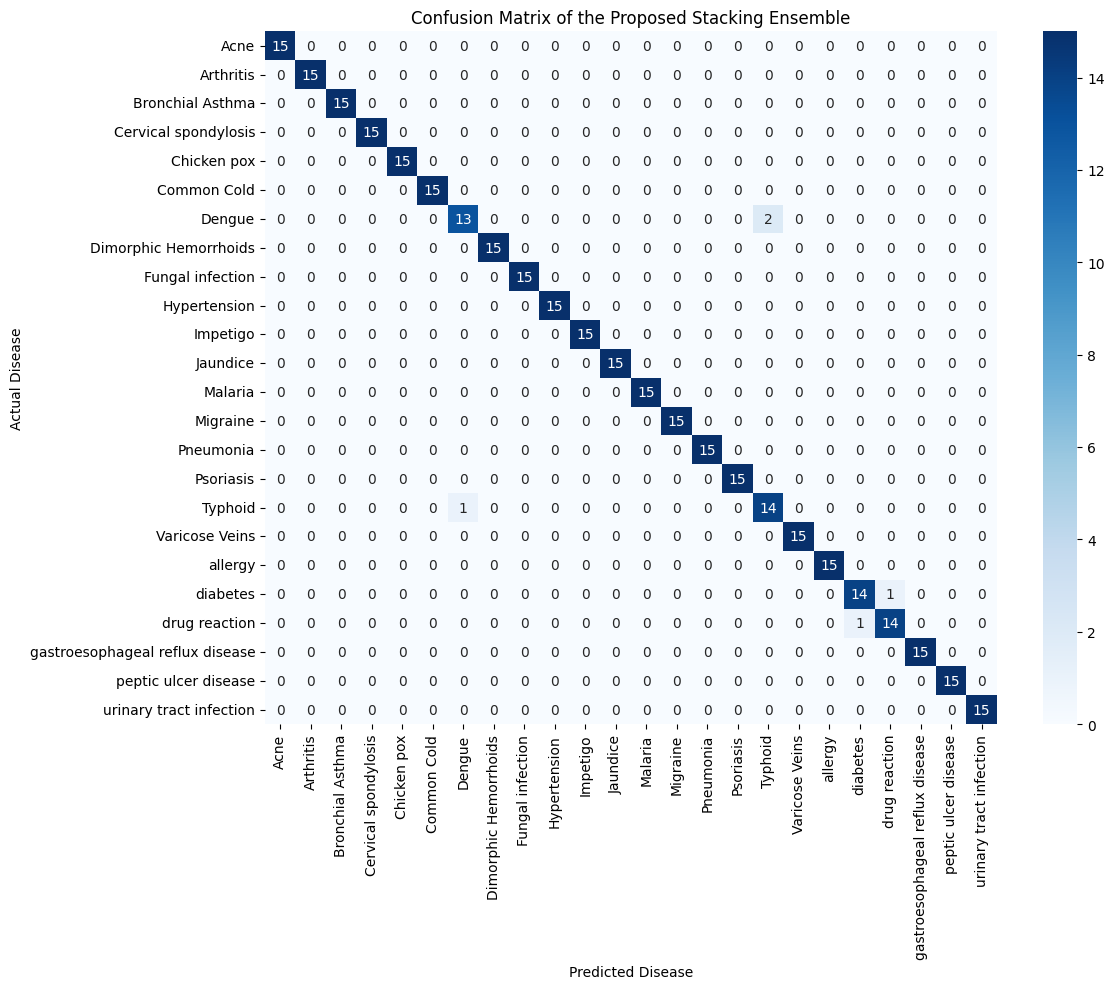


Generating Figure 5.7...


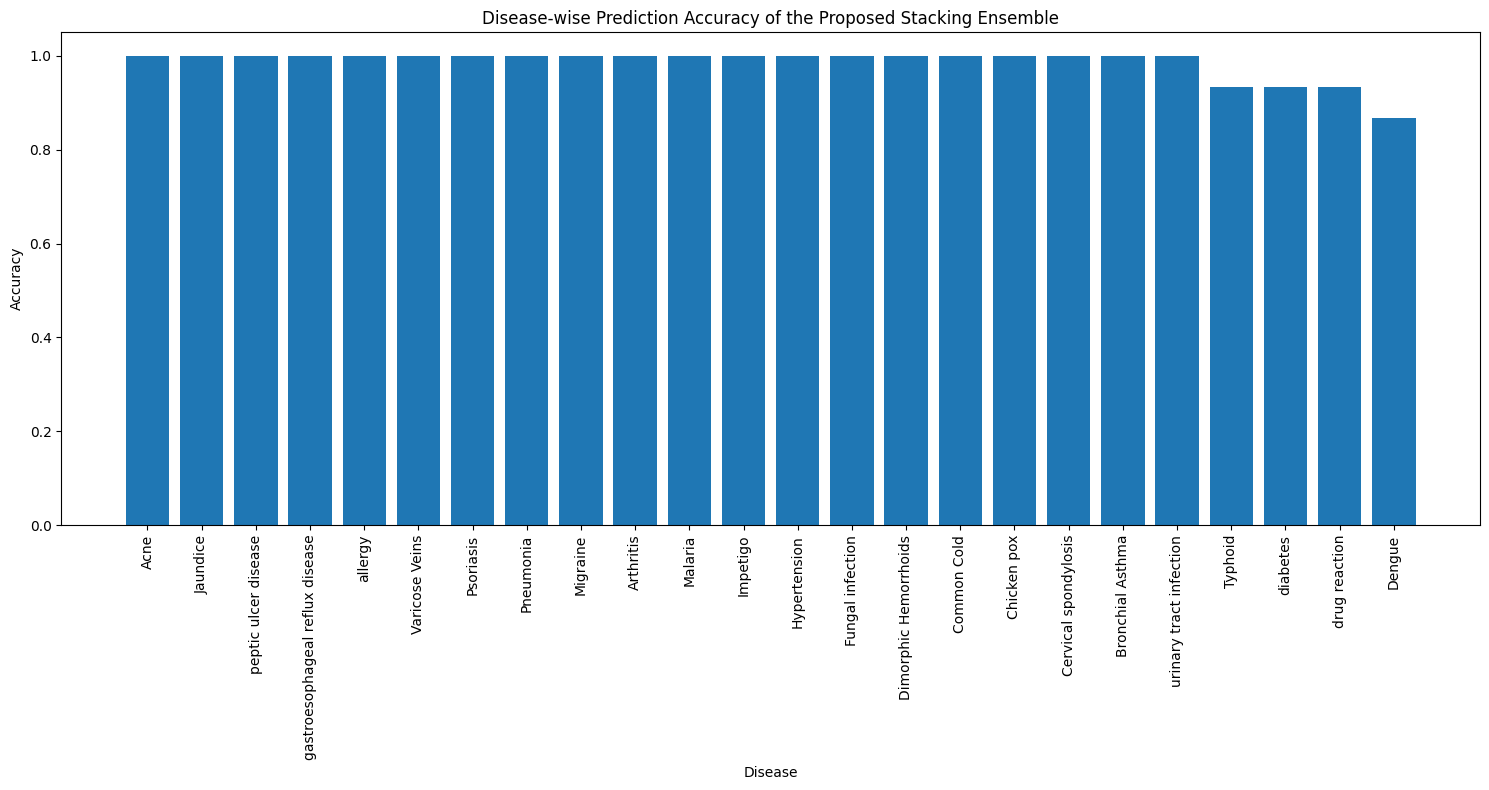


Generating Figure 5.8...


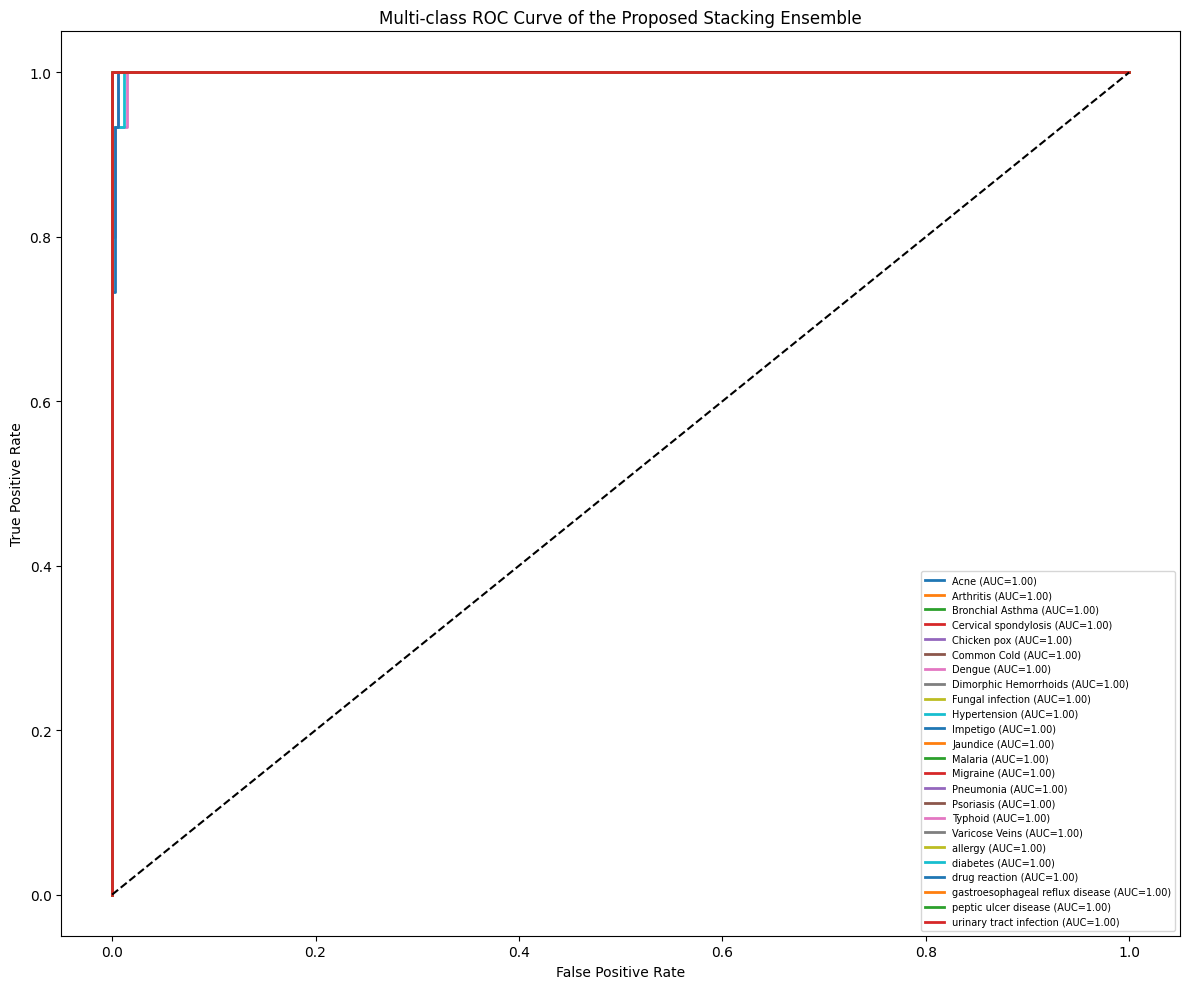


Figures generated successfully.
Accuracy: 0.9861111111111112
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        15
                      Arthritis       1.00      1.00      1.00        15
               Bronchial Asthma       1.00      1.00      1.00        15
           Cervical spondylosis       1.00      1.00      1.00        15
                    Chicken pox       1.00      1.00      1.00        15
                    Common Cold       1.00      1.00      1.00        15
                         Dengue       0.93      0.87      0.90        15
          Dimorphic Hemorrhoids       1.00      1.00      1.00        15
               Fungal infection       1.00      1.00      1.00        15
                   Hypertension       1.00      1.00      1.00        15
                       Impetigo       1.00      1.00      1.00        15
                       Jaundice       1.00      1.00      1.0

In [5]:
import pandas as pd
import numpy as np
import joblib
import pickle
import re
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Layer

import tensorflow as tf


# ==========================================
# CREATE ENSEMBLE SAVE FOLDER
# ==========================================

os.makedirs("models/ensembles", exist_ok=True)


# ==========================================
# CUSTOM ATTENTION LAYER
# ==========================================

class AttentionLayer(Layer):

    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):

        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], input_shape[-1]),
            initializer='glorot_uniform',
            trainable=True
        )

        self.b = self.add_weight(
            name='attention_bias',
            shape=(input_shape[-1],),
            initializer='zeros',
            trainable=True
        )

        self.u = self.add_weight(
            name='context_vector',
            shape=(input_shape[-1],),
            initializer='glorot_uniform',
            trainable=True
        )

        super(AttentionLayer, self).build(input_shape)

    def call(self, x):

        score = tf.nn.tanh(
            tf.tensordot(x, self.W, axes=[2,0]) + self.b
        )

        attention_weights = tf.nn.softmax(
            tf.tensordot(score, self.u, axes=[2,0]),
            axis=1
        )

        context_vector = tf.reduce_sum(
            attention_weights[..., tf.newaxis] * x,
            axis=1
        )

        return context_vector


# ==========================================
# LOAD MODELS
# ==========================================

print("Loading models...")

rf = joblib.load("models/random_forest_model.pkl")
svm = joblib.load("models/svm_model.pkl")
lr = joblib.load("models/logistic_regression_model.pkl")
xgb = joblib.load("models/xgboost_model.pkl")

label_encoder = joblib.load(
    "models/label_encoder.pkl"
)

bilstm_model = load_model(
    "models/disease_prediction_model.h5",
    custom_objects={
        "AttentionLayer": AttentionLayer
    }
)

with open(
    "models/preprocessing.pkl",
    "rb"
) as f:
    preprocess = pickle.load(f)

tokenizer = preprocess["tokenizer"]

max_len = 150

print("Models loaded successfully")

# ==========================================
# STACKING ENSEMBLE
# ==========================================

def evaluate_stacking():

    print("\nGenerating Stacking Ensemble...")

    # --------------------------------------
    # BASE MODEL PROBABILITIES
    # --------------------------------------

    text_probs = bilstm_predict_batch(
        X_text_test
    )

    rf_probs = rf.predict_proba(
        X_tab_test
    )

    svm_probs = svm.predict_proba(
        X_tab_test
    )

    lr_probs = lr.predict_proba(
        X_tab_test
    )

    xgb_probs = xgb.predict_proba(
        X_tab_test
    )

    # --------------------------------------
    # CREATE META FEATURES
    # --------------------------------------

    meta_features = np.hstack([
        text_probs,
        rf_probs,
        svm_probs,
        lr_probs,
        xgb_probs
    ])

    # --------------------------------------
    # META LEARNER
    # --------------------------------------

    meta_model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    meta_model.fit(
        meta_features,
        y_test
    )

    # --------------------------------------
    # PREDICTIONS
    # --------------------------------------

    stack_preds = meta_model.predict(
        meta_features
    )

    stack_probs = meta_model.predict_proba(
        meta_features
    )

    # --------------------------------------
    # ACCURACY
    # --------------------------------------

    acc = accuracy_score(
        y_test,
        stack_preds
    )

    report = classification_report(
        y_test,
        stack_preds,
        target_names=label_encoder.classes_,
        zero_division=0
    )

    # --------------------------------------
    # SAVE STACKING MODEL
    # --------------------------------------

    joblib.dump(
        meta_model,
        "models/ensembles/stacking_meta_model.pkl"
    )

    # ======================================
    # FIGURE 5.6
    # CONFUSION MATRIX
    # ======================================

    print(
        "\nGenerating Figure 5.6..."
    )

    cm = confusion_matrix(
        y_test,
        stack_preds
    )

    plt.figure(
        figsize=(12,10)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.xlabel(
        "Predicted Disease"
    )

    plt.ylabel(
        "Actual Disease"
    )

    plt.title(
        "Confusion Matrix of the Proposed Stacking Ensemble"
    )

    plt.tight_layout()

    plt.savefig(
        "Figure_5_6_Confusion_Matrix_Stacking.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ======================================
    # FIGURE 5.7
    # DISEASE-WISE ACCURACY
    # ======================================

    print(
        "\nGenerating Figure 5.7..."
    )

    disease_accuracy = (
        cm.diagonal() /
        cm.sum(axis=1)
    )

    accuracy_df = pd.DataFrame({
        "Disease": label_encoder.classes_,
        "Accuracy": disease_accuracy
    })

    accuracy_df = accuracy_df.sort_values(
        by="Accuracy",
        ascending=False
    )

    plt.figure(
        figsize=(15,8)
    )

    plt.bar(
        accuracy_df["Disease"],
        accuracy_df["Accuracy"]
    )

    plt.xticks(
        rotation=90
    )

    plt.xlabel(
        "Disease"
    )

    plt.ylabel(
        "Accuracy"
    )

    plt.title(
        "Disease-wise Prediction Accuracy of the Proposed Stacking Ensemble"
    )

    plt.tight_layout()

    plt.savefig(
        "Figure_5_7_Disease_Wise_Accuracy.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ======================================
    # FIGURE 5.8
    # MULTI-CLASS ROC
    # ======================================

    print(
        "\nGenerating Figure 5.8..."
    )

    n_classes = len(
        label_encoder.classes_
    )

    y_test_bin = label_binarize(
        y_test,
        classes=np.arange(n_classes)
    )

    plt.figure(
        figsize=(12,10)
    )

    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            stack_probs[:, i]
        )

        roc_auc = auc(
            fpr,
            tpr
        )

        plt.plot(
            fpr,
            tpr,
            lw=2,
            label=f"{label_encoder.classes_[i]} (AUC={roc_auc:.2f})"
        )

    plt.plot(
        [0,1],
        [0,1],
        'k--'
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.title(
        "Multi-class ROC Curve of the Proposed Stacking Ensemble"
    )

    plt.legend(
        loc="lower right",
        fontsize=7
    )

    plt.tight_layout()

    plt.savefig(
        "Figure_5_8_Multiclass_ROC_Stacking.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "\nFigures generated successfully."
    )

    return acc, report


print("\nStacking Ensemble")
acc5, rep5 = evaluate_stacking()
print("Accuracy:", acc5)
print(rep5)